In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("student-por.csv")

In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
df.isnull().sum()


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [5]:
cols = ['schoolsup','famsup','paid','activities','nursery','higher','internet','romantic']
for col in cols:
    df[col] = df[col].map({'yes':1, 'no':0})


In [6]:
df = pd.get_dummies(df, drop_first=True)


<Axes: xlabel='studytime', ylabel='G3'>

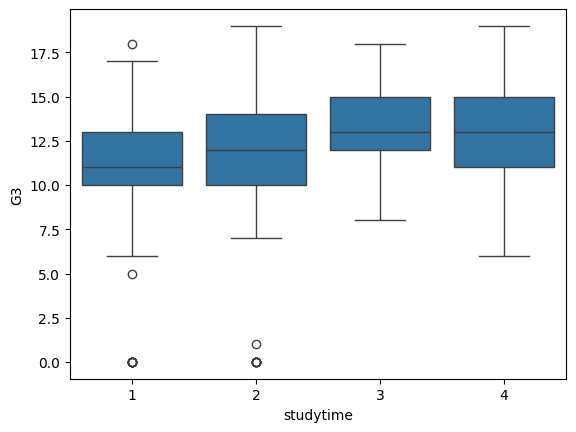

In [7]:
sns.boxplot(x=df['studytime'], y=df['G3'])

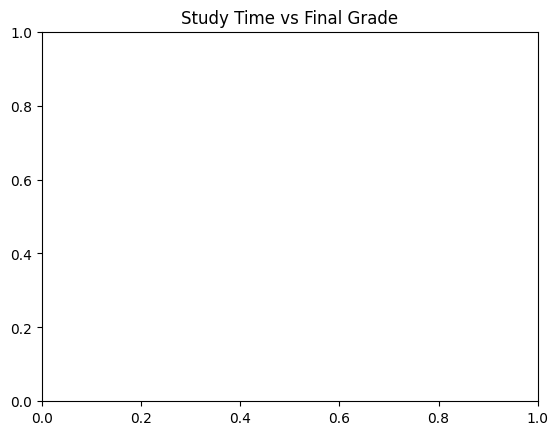

In [10]:
plt.title("Study Time vs Final Grade")
plt.show()

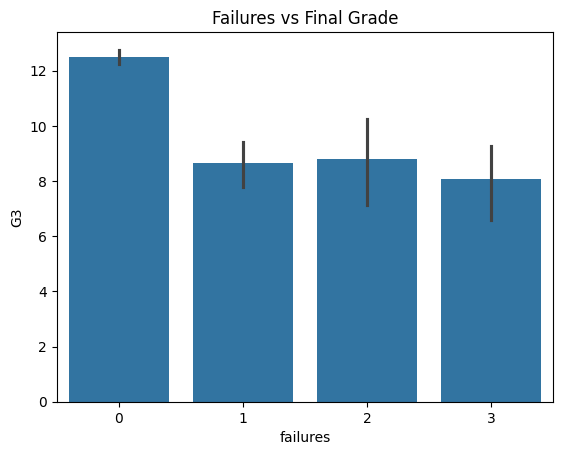

In [11]:
sns.barplot(x=df['failures'], y=df['G3'])
plt.title("Failures vs Final Grade")
plt.show()


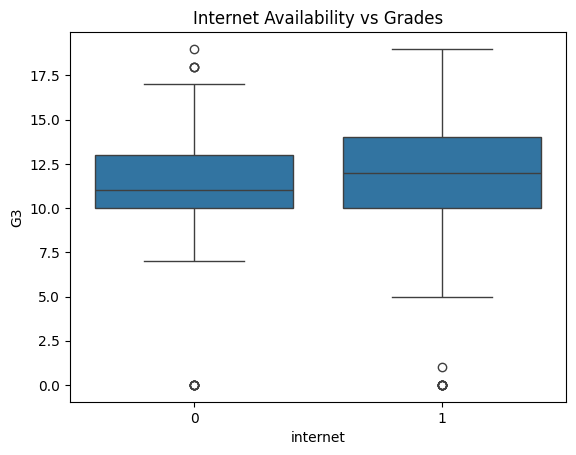

In [12]:
sns.boxplot(x=df['internet'], y=df['G3'])
plt.title("Internet Availability vs Grades")
plt.show()


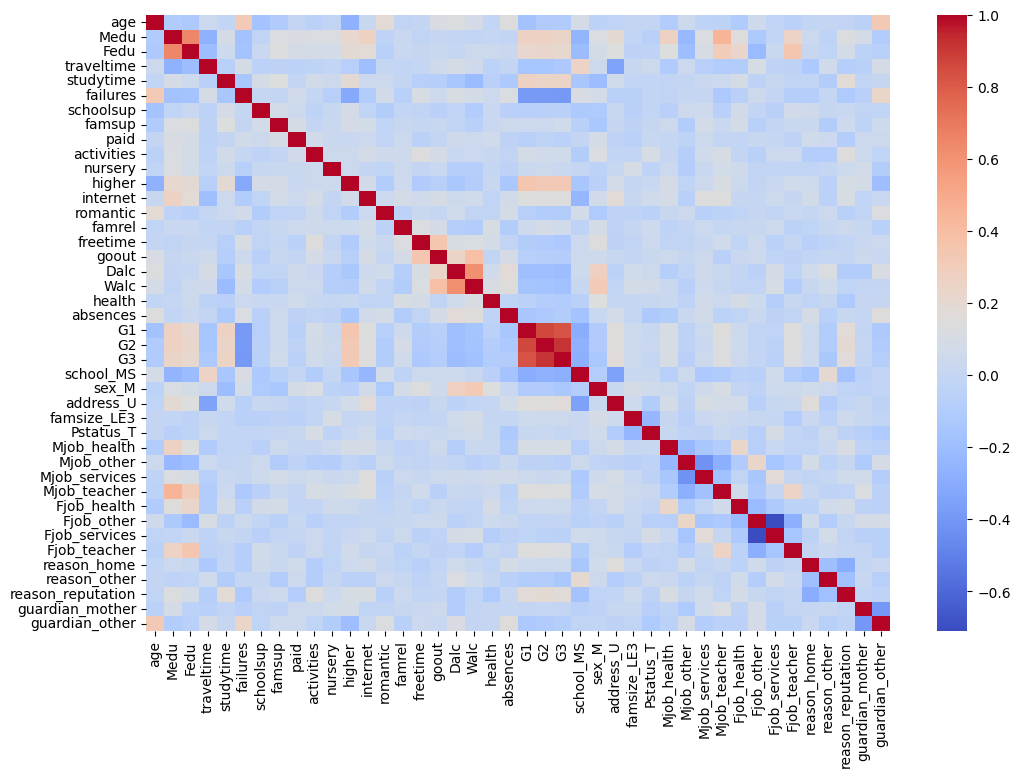

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()


In [14]:
from sklearn.model_selection import train_test_split



In [15]:
X = df.drop('G3', axis=1)
y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [17]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R2 Score: 0.8486513286537314
MAE: 0.7650597682758263


In [18]:
import joblib


In [19]:
joblib.dump(model, "student_performance_model.pkl")


['student_performance_model.pkl']

In [20]:
loaded_model = joblib.load("student_performance_model.pkl")

# Predict using loaded model
loaded_pred = loaded_model.predict(X_test)
print(loaded_pred[:5])


[18.40265613 11.82720849 18.56288575 10.80969554 11.74323992]


In [23]:


print("Pipeline saved successfully!")

Pipeline saved successfully!


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
import pickle

# ---------------------------------------
# LOAD DATA
# ---------------------------------------
df = pd.read_csv("student-por.csv")

# Target
y = df["G3"]
X = df.drop("G3", axis=1)

# ---------------------------------------
# CATEGORICAL / NUMERIC SPLIT
# ---------------------------------------
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

# ---------------------------------------
# PREPROCESSOR
# ---------------------------------------
preprocess = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("numeric", StandardScaler(), num_cols)
])

# ---------------------------------------
# FULL PIPELINE → preprocess + model
# ---------------------------------------
pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

# ---------------------------------------
# TRAIN
# ---------------------------------------
pipeline.fit(X, y)

# ---------------------------------------
# SAVE THE FULL PIPELINE
# ---------------------------------------
with open("student_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("✅ Saved full pipeline successfully!")


✅ Saved full pipeline successfully!


In [3]:
import pandas as pd
import pickle

df = pd.read_csv("student-por.csv")

pipeline = pickle.load(open("student_pipeline.pkl", "rb"))

sample = df.drop("G3", axis=1).iloc[[0]]

print(pipeline.predict(sample))


[9.93603516]
